3rd Test - Cane segmentation - Image 2750 - 512x512


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

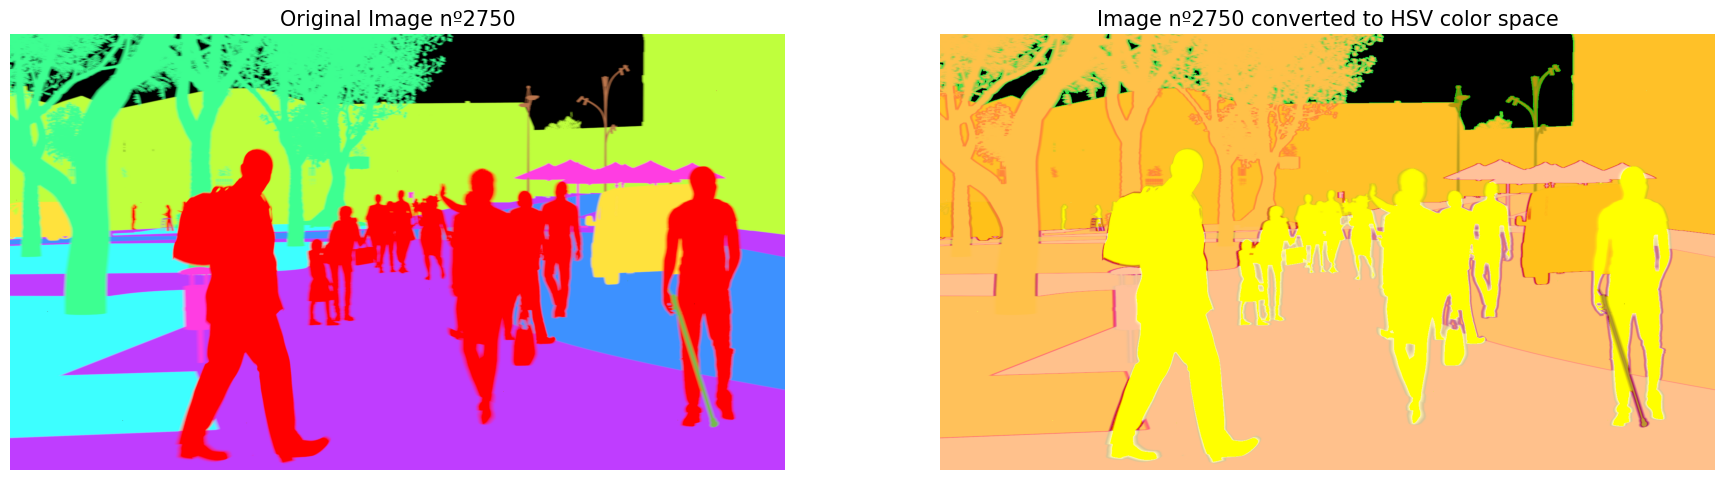

In [ ]:
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
# base_mask_folder: str = r"C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask"
# output_folder: str = os.getenv("OUTPUT_FOLDER")
# mask_path: str = os.path.join(base_mask_folder, f"{441}.png")

base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting HSV image
plt.subplot(122)
plt.imshow(hsv_img[:,:,::-1])
plt.title(f"Image nº{img_number} converted to HSV color space",fontdict={'fontsize': 15})
plt.axis('off')


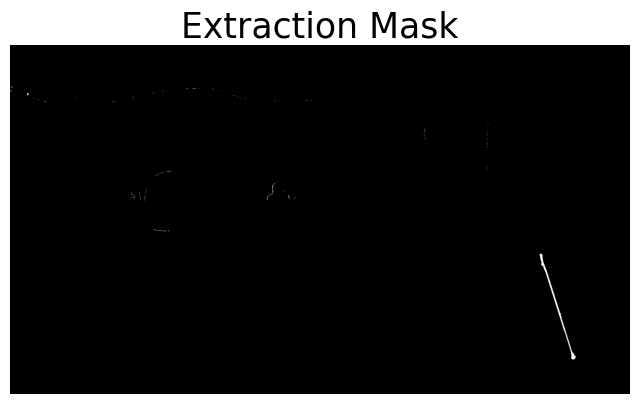

In [3]:
### Process 1 - Extraction of the desired color ###
# Define limits for the color you want to extract in HSV
lower_bound = np.array([32, 77, 163]) # Hue, Saturation, Value
upper_bound = np.array([72, 163, 214]) # Hue, Saturation, Value
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)

# Display the extraction mask
plt.figure(figsize=[8, 8])
plt.imshow(mask_extraction, cmap='gray')
plt.title("Extraction Mask", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()


'\nResult: Effective on simple objects\nUpdate: After refactor the code now it is possible filter the noise with complex objects\n\nConsider process and min_area as a factor to refactor the image_manipulation.py\n'

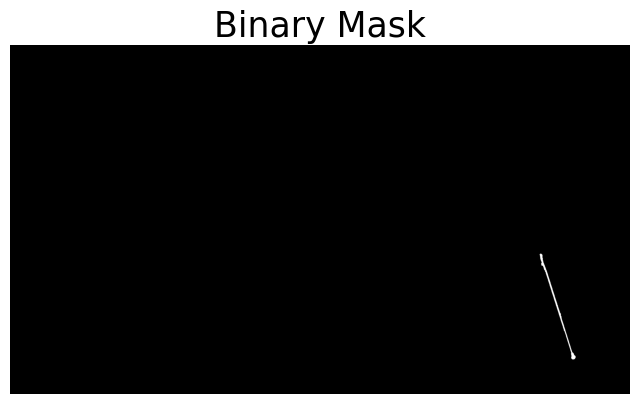

In [ ]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask_extraction, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask_extraction)

# Define minimum area
min_area = 20

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask_extraction)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask_extraction, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask3 = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask3, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result: Effective on simple objects
Update: After refactor the code now it is possible filter the noise with complex objects

Consider process and min_area as a factor to refactor the image_manipulation.py
"""

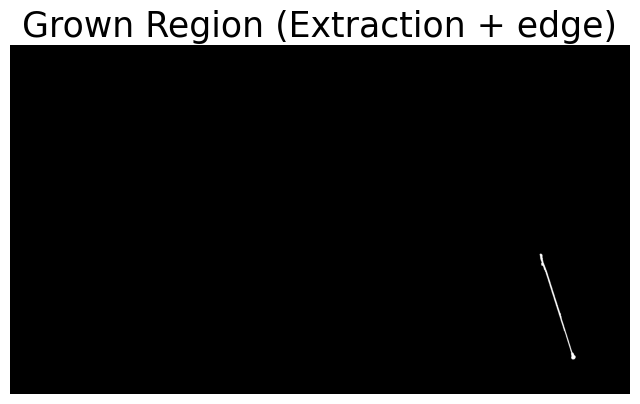

In [ ]:
import collections

### Define target color ###
# Average extraction range: ((32+72)//2, (77+163)//2, (163+214)//2) = [52, 120, 188]
target_color = np.array([(32 + 72) // 2, (77 + 163) // 2, (163 + 214) // 2])

### Region growing from extraction ###
# A region growing mask is created. Initially, it contains the extraction.
region_mask = np.zeros_like(mask3, dtype=np.uint8)
region_mask[mask3 == 255] = 255

# We use a queue to implement region growth
queue = collections.deque()

# We add the initial pixels of the extraction
indexes = np.column_stack(np.where(mask3 == 255))
for index in indexes:
    queue.append(tuple(index))

# Helper function: boundary condition based on the obtained ranges in HSV
def fulfill_condition(H, S, V):
    # For the Hue component, it is considered to be on the edge if it is >=151 or <=18 (circular logic)
    cane_condition = ((H >= 151 or H <= 18) and (72 <= S <= 193) and (166 <= V <= 251))
    return cane_condition

# We perform the growth: for each pixel in the region, its neighbors are analyzed.
while queue:
    i, j = queue.popleft()
    # For 8 Neighbors (it's possible expand the neighborhood if necessary)
    for di, dj in [
                    (-1, -1), (-1, 0), (-1, 1),
                    (0, -1),           (0, 1),
                    (1, -1),  (1, 0),  (1, 1)
                ]:
        ni, nj = i + di, j + dj
        # Check that the neighbor is within the image
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # If the neighbor is not yet part of the growth region:
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))

# Display the grown region
plt.figure(figsize=[8, 8])
plt.imshow(region_mask, cmap='gray')
plt.title("Grown Region (Extraction + edge)", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

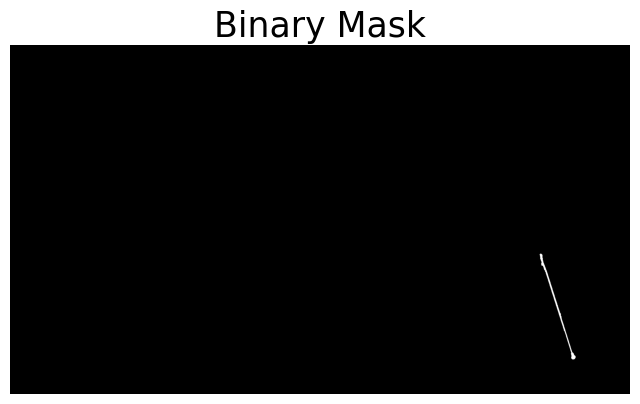

In [11]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8) # Better result
# mask2 = cv.morphologyEx(region_mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask2 = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel) # Close small holes


plt.figure(figsize=[8,8])
plt.imshow(mask2, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

Image After Resize: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

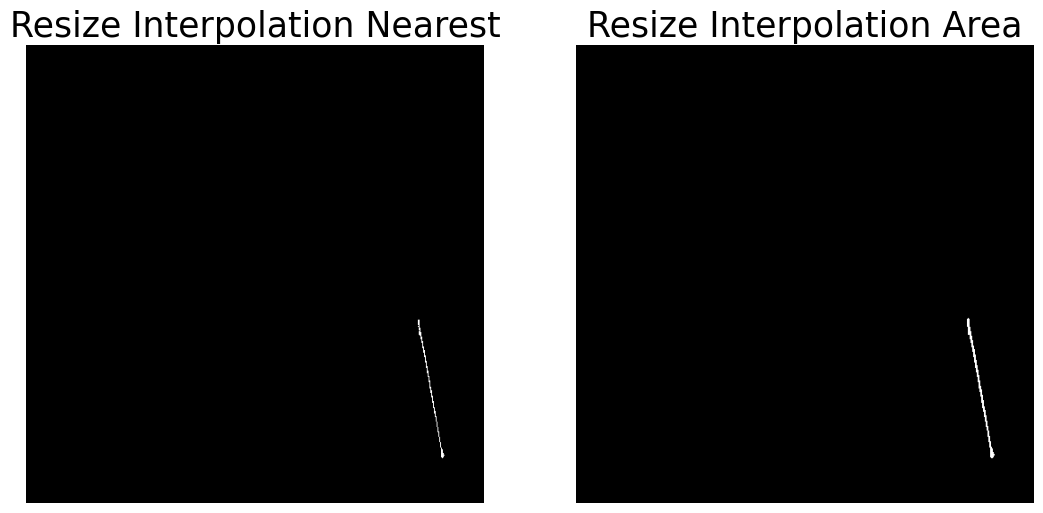

In [12]:
# Test: Resize mask and image
mask4a = cv.resize(mask3, (512, 512), interpolation=cv.INTER_NEAREST) # less defined
mask4b = cv.resize(mask3, (512, 512), interpolation=cv.INTER_AREA)    # chosen: cane is better defined
# Re-Binarize
mask4a = np.where(mask4a > 0, 255, 0).astype(np.uint8) 
mask4b = np.where(mask4b > 0, 255, 0).astype(np.uint8) 
print('Image After Resize:', mask4b.shape)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting mask 4a
plt.subplot(121)
plt.imshow(mask4a, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting mask 4b
plt.subplot(122)
plt.imshow(mask4b, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

In [13]:
# cv.imshow("Inspect Image", mask4a)   # Mask 1 (512x512 - Nearest)
cv.imshow("Inspect Image", mask4b)   # Mask 2 (512x512 - Area)

cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

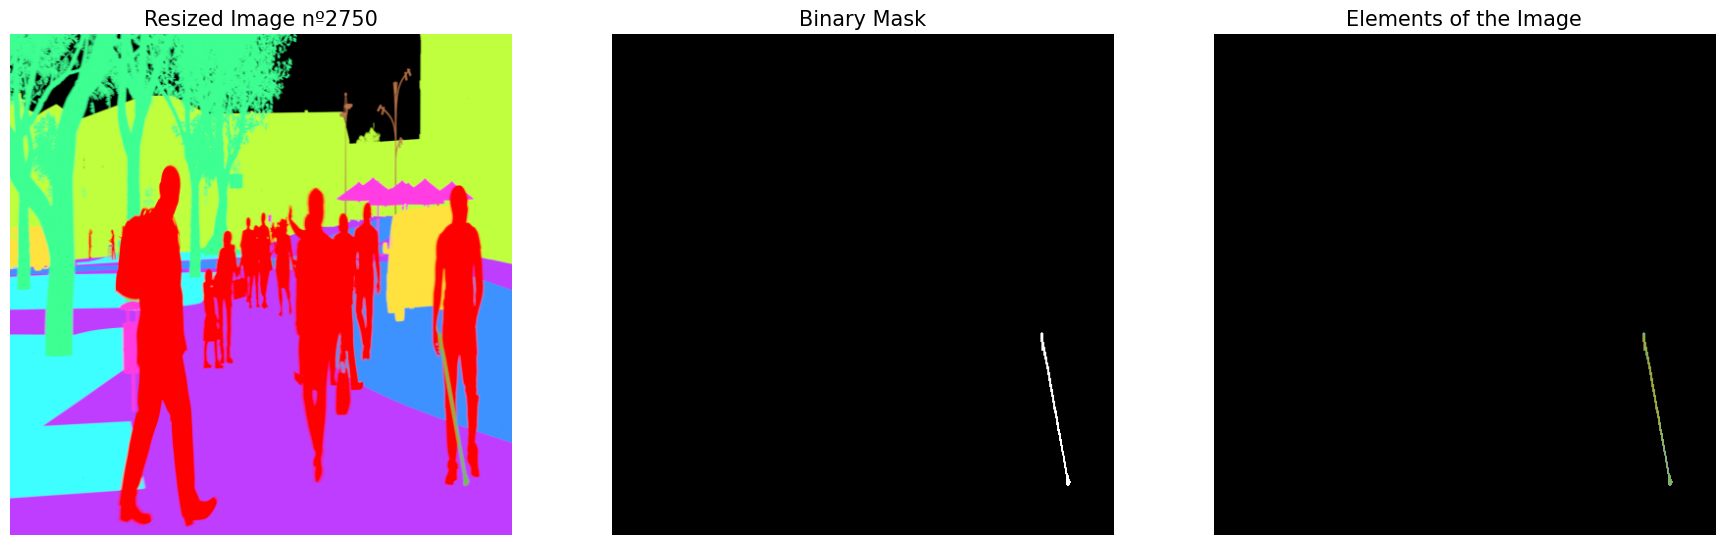

In [14]:
# Visualize Segmentation

# Resize Original Image
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask4b)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(131)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting binary mask
plt.subplot(132)
plt.imshow(mask4b, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting result
plt.subplot(133)
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':15})
plt.axis('off')

4th Test - Cane Segmentation - Image 2635 - 512x512

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

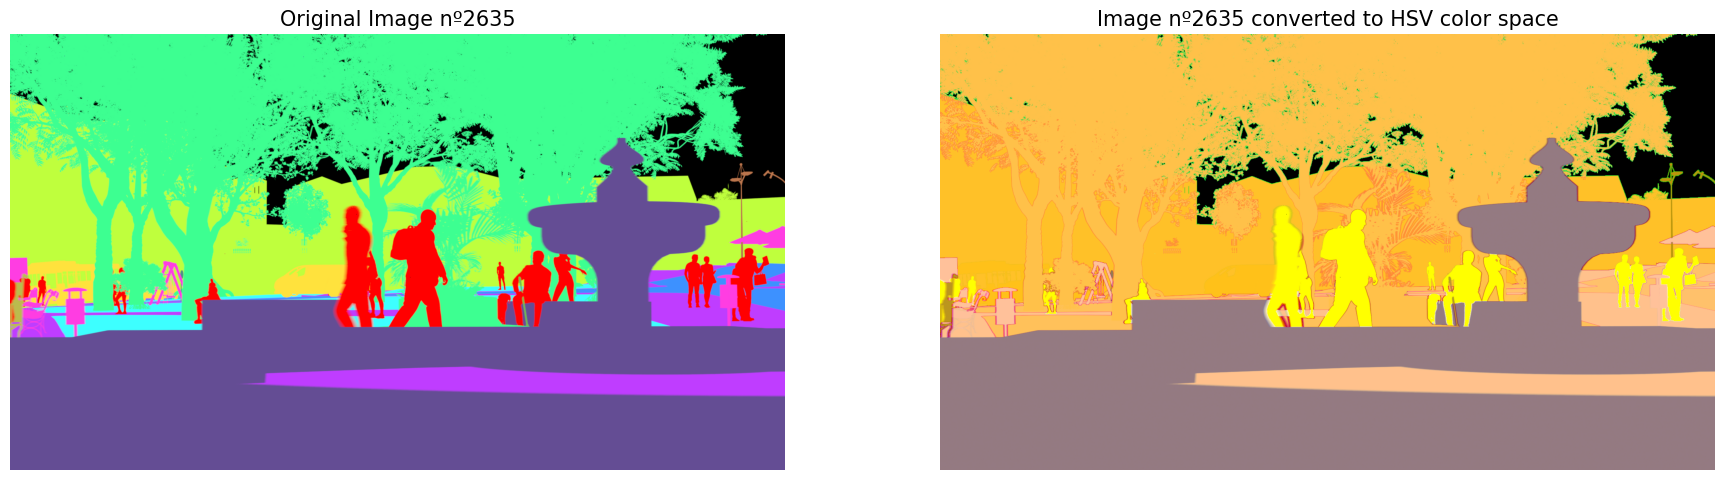

In [ ]:
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
# base_mask_folder: str = r"C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask"
# output_folder: str = os.getenv("OUTPUT_FOLDER")
# mask_path: str = os.path.join(base_mask_folder, f"{441}.png")

base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting HSV image
plt.subplot(122)
plt.imshow(hsv_img[:,:,::-1])
plt.title(f"Image nº{img_number} converted to HSV color space",fontdict={'fontsize': 15})
plt.axis('off')


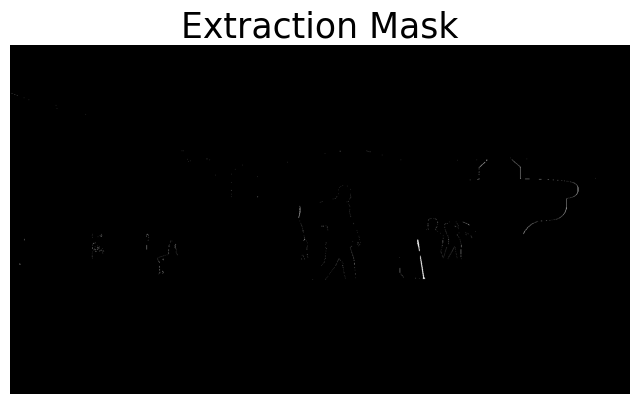

In [67]:
### Process 1 - Extraction of the desired color ###
# Define limits for the color you want to extract in HSV
lower_bound = np.array([32, 77, 163]) # Hue, Saturation, Value
upper_bound = np.array([72, 163, 214]) # Hue, Saturation, Value
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)

# Display the extraction mask
plt.figure(figsize=[8, 8])
plt.imshow(mask_extraction, cmap='gray')
plt.title("Extraction Mask", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

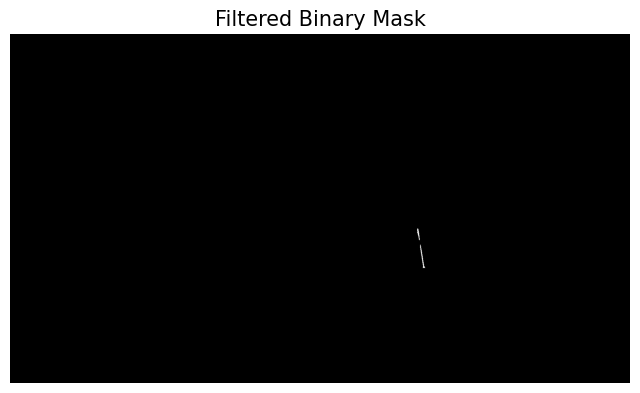

In [70]:
import cv2 as cv
import numpy as np

# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask_extraction, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask_extraction)

# Define minimum area
min_area = 20

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask_extraction)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask_extraction, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(filtered_mask, cmap='gray')
plt.title("Filtered Binary Mask",fontdict={'fontsize': 15})
plt.axis('off')

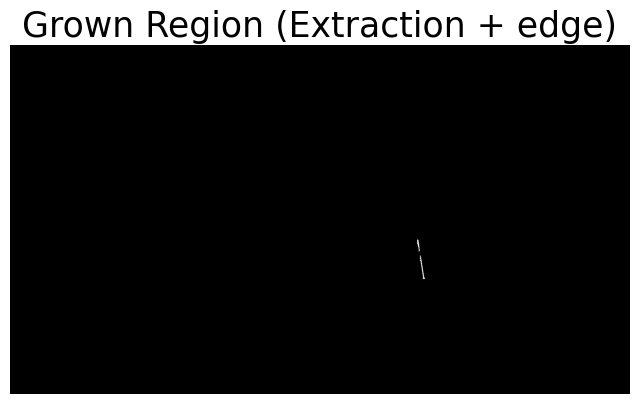

In [ ]:
import collections

### Define target color ###
# Average extraction range: ((32+72)//2, (77+163)//2, (163+214)//2) = [52, 120, 188]
target_color = np.array([(32 + 72) // 2, (77 + 163) // 2, (163 + 214) // 2])

### Region growing from extraction ###
# A region growing mask is created. Initially, it contains the extraction.
region_mask = np.zeros_like(filtered_mask, dtype=np.uint8)
region_mask[filtered_mask == 255] = 255

# We use a queue to implement region growth
queue = collections.deque()

# We add the initial pixels of the extraction
indexes = np.column_stack(np.where(filtered_mask == 255))
for index in indexes:
    queue.append(tuple(index))

# Helper function: boundary condition based on the obtained ranges in HSV
def fulfill_condition(H, S, V):
    # For the Hue component, it is considered to be on the edge if it is >=151 or <=18 (circular logic)
    cane_condition = ((H >= 151 or H <= 18) and (72 <= S <= 193) and (166 <= V <= 251))
    return cane_condition

# We perform the growth: for each pixel in the region, its neighbors are analyzed.
while queue:
    i, j = queue.popleft()
    # For 8 Neighbors (it's possible expand the neighborhood if necessary)
    for di, dj in [
                    (-1, -1), (-1, 0), (-1, 1),
                    (0, -1),           (0, 1),
                    (1, -1),  (1, 0),  (1, 1)
                ]:
        ni, nj = i + di, j + dj
        # Check that the neighbor is within the image
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # If the neighbor is not yet part of the growth region:
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))

# Display the grown region
plt.figure(figsize=[8, 8])
plt.imshow(region_mask, cmap='gray')
plt.title("Grown Region (Extraction + edge)", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

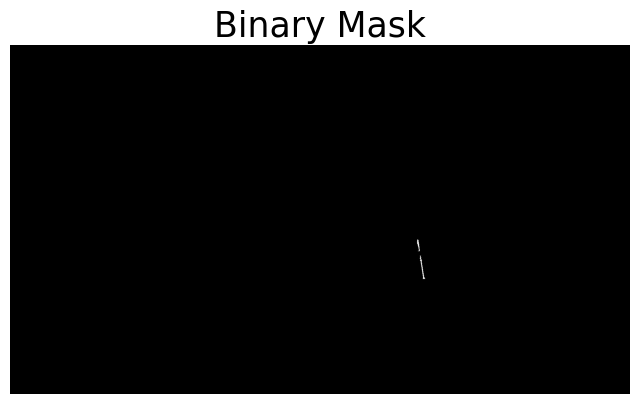

In [61]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
# mask = cv.morphologyEx(region_mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [62]:
# Inspect the mask
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

Image After Resize: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

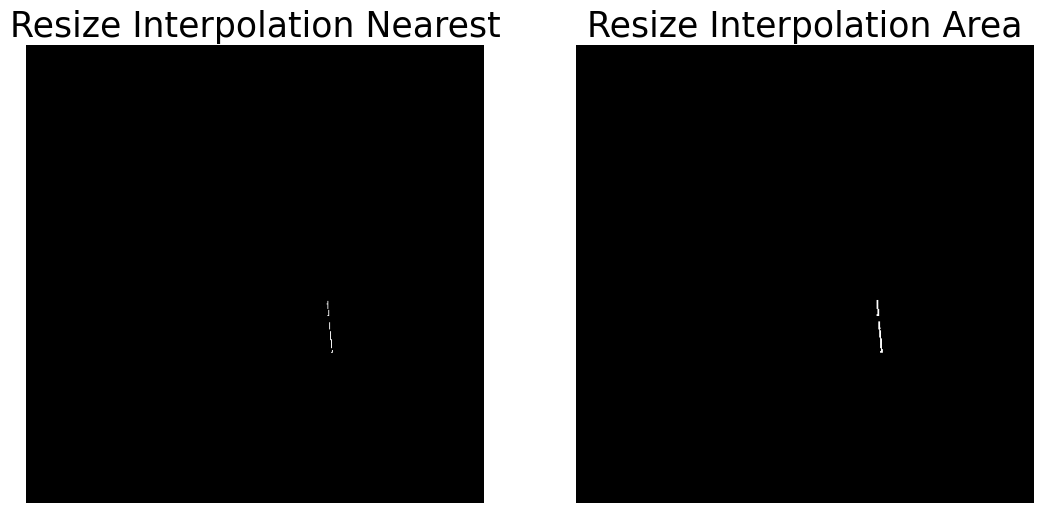

In [63]:
# Test: Resize mask and image
mask1 = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)
mask2 = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA) # Better result
# Re-Binarize
mask1 = np.where(mask1 > 0, 255, 0).astype(np.uint8)
mask2 = np.where(mask2 > 0, 255, 0).astype(np.uint8)
print('Image After Resize:', mask2.shape)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask1, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

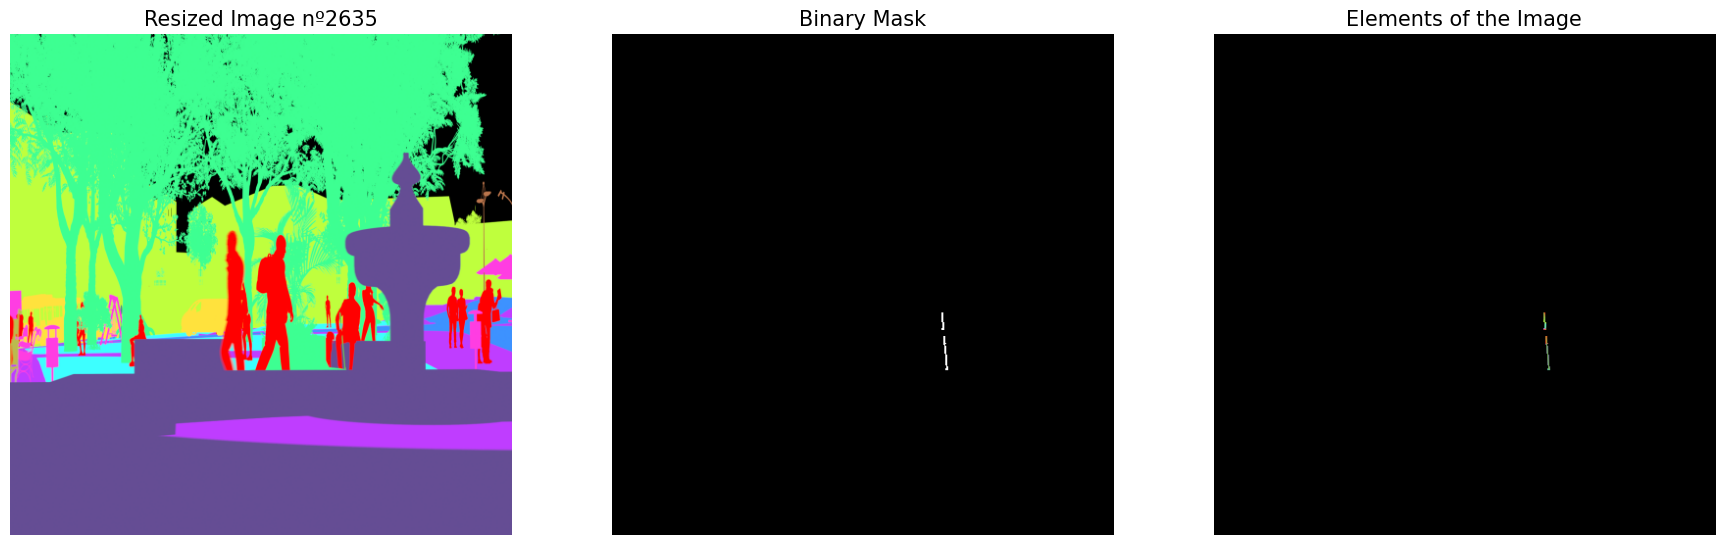

In [64]:
# Visualize Segmentation

# Resize Original Image
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask2)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(131)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting binary mask
plt.subplot(132)
plt.imshow(mask2, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting result
plt.subplot(133)
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':15})
plt.axis('off')